In [242]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm, trange
import re
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

In [243]:
data = pd.read_csv('dump3.csv')

In [244]:
data.shape

(83707, 5)

In [245]:
data.head(5)

,name,Артикул,category,Цена без карты,Цена с картой
0,Проходка BORGE Кровельная D6-50мм прямая №1,17162301,"Главная,Каталог,Строительные материалы,Кровля,...",329.33 ₽,312.86 ₽
1,Аэратор ТЕХНОНИКОЛЬ КТВ,17575401,"Главная,Каталог,Строительные материалы,Кровля,...",1 529.00 ₽,1 452.55 ₽
2,Аэратор ТЕХНОНИКОЛЬ Pilot скатный,17575301,"Главная,Каталог,Строительные материалы,Кровля,...",3 008.00 ₽,2 857.60 ₽
3,Проходной элемент ТЕХНОНИКОЛЬ Shinglas,17575701,"Главная,Каталог,Строительные материалы,Кровля,...",1 172.00 ₽,1 113.40 ₽
4,Вентиль ТЕХНОНИКОЛЬ Skat кровельный,17575501,"Главная,Каталог,Строительные материалы,Кровля,...",2 396.00 ₽,2 276.20 ₽


In [246]:
print(data['category'].unique(), len(data['category'].unique()))

['Главная,Каталог,Строительные материалы,Кровля,Вентиляция для кровли'
 'Главная,Каталог,Строительные материалы,Кровля,Волнистый лист (ондулин)'
 'Главная,Каталог,Строительные материалы,Кровля,Кровельные мастики'
 'Главная,Каталог,Строительные материалы,Кровля,Кровельные ограждения, снегодержатели'
 'Главная,Каталог,Строительные материалы,Кровля,Металлочерепица'
 'Главная,Каталог,Строительные материалы,Кровля,Мягкая черепица'
 'Главная,Каталог,Строительные материалы,Кровля,Профнастил'
 'Главная,Каталог,Строительные материалы,Кровля,Рулонная кровля'
 'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Затирки'
 'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Клеи'
 'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Ровнители для пола'
 'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Специальные смеси'
 'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Шпаклевки'
 'Главная,Катал

In [247]:
print(data['name'].unique(), len(data['name'].unique()))

['Проходка BORGE Кровельная D6-50мм прямая №1' 'Аэратор ТЕХНОНИКОЛЬ КТВ'
 'Аэратор ТЕХНОНИКОЛЬ Pilot скатный' ...
 'Решётка заборная FULEREN 15х15 0,5х5мх'
 'Решётка заборная FULEREN 15х15 0,5х10м'
 'Сетка сварная FULEREN Оцинкованная 50х100 1,8х15м'] 82921


# Выборка данных

In [387]:
topics = set(data.category)
pack_in_cat = 150

In [388]:
df_res = pd.DataFrame()

for topic in tqdm(topics):
    df_topic = data[data['category'] == topic][:pack_in_cat]
    df_res = df_res.append(df_topic)

  0%|          | 0/872 [00:00<?, ?it/s]

In [389]:
df_res.shape

(47959, 5)


# Предобработка

In [390]:
import string
def remove_punctuation(text):
    return "".join([ch if ch not in string.punctuation else ' ' for ch in text])

def remove_numbers(text):
    return ''.join([i if not i.isdigit() else ' ' for i in text])

import re
def remove_multiple_spaces(text):
	return re.sub(r'\s+', ' ', text, flags=re.I)

import nltk
nltk.download('stopwords')
from nltk.stem import *
from nltk.corpus import stopwords
from pymystem3 import Mystem
from string import punctuation
mystem = Mystem() 

russian_stopwords = stopwords.words("russian")
russian_stopwords.extend(['…', '«', '»', '...'])
def lemmatize_text(text):
    tokens = mystem.lemmatize(text.lower())
    tokens = [token for token in tokens if token not in russian_stopwords and token != " "]
    text = " ".join(tokens)
    return text

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/mugichu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<ipython-input-391-6083d33376df>:26: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(1, 2, 1)


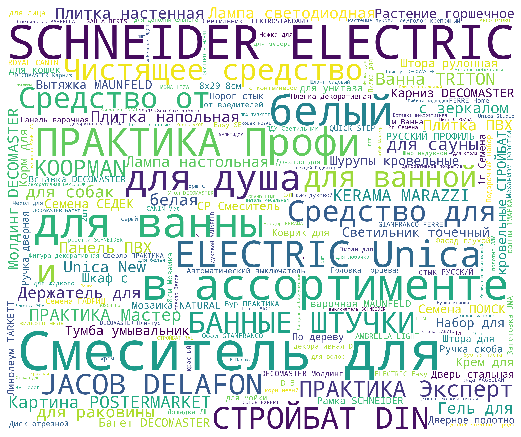

In [391]:
def str_corpus(corpus):
    str_corpus = ''
    for i in corpus:
        str_corpus += ' ' + i
    str_corpus = str_corpus.strip()
    return str_corpus
# Получение списка всех слов в корпусе
def get_corpus(data):
    corpus = []
    for phrase in data:
        for word in phrase.split():
            corpus.append(word)
    return corpus
# Получение облака слов
def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',width=3000,height=2500,max_words=200,random_state=42).generate(str_corpus(corpus))
    return wordCloud

corpus = get_corpus(df_res['name'].values)
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

In [392]:
prep_text = [remove_multiple_spaces(remove_numbers(remove_punctuation(text.lower()))) for text in tqdm(df_res['name'])]


  0%|          | 0/47959 [00:00<?, ?it/s]

In [393]:
len(prep_text)
prep_text[1]

'лебёдка автомобильная stayer '

In [394]:
df_res['text_prep'] = prep_text
df_res.head(1)

,name,Артикул,category,Цена без карты,Цена с картой,text_prep
13220,Лебёдка автомобильная ЗУБР 43105-2,168437,"Главная,Каталог,Инструменты и крепёж,Подъём и ...",3 184.01 ₽,3 024.81 ₽,лебёдка автомобильная зубр


In [395]:
from nltk.stem.snowball import SnowballStemmer 
stemmer = SnowballStemmer("russian")

In [396]:
russian_stopwords = stopwords.words("russian")
russian_stopwords.extend(['…', '«', '»', '...', 'т.д.', 'т', 'д','Главная','Каталог'])

In [397]:
import nltk
nltk.download('punkt')
from nltk import word_tokenize
text = df_res['text_prep'][0]
word_tokenize(text)

[nltk_data] Downloading package punkt to /home/mugichu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


['проходка', 'borge', 'кровельная', 'd', 'мм', 'прямая', '№']

In [398]:
from nltk import word_tokenize

stemmed_texts_list = []
for text in tqdm(df_res['text_prep']):
    tokens = word_tokenize(text)    
    stemmed_tokens = [stemmer.stem(token) for token in tokens if token not in russian_stopwords]
    text = " ".join(stemmed_tokens)
    stemmed_texts_list.append(text)

df_res['text_stem'] = stemmed_texts_list

  0%|          | 0/47959 [00:00<?, ?it/s]

In [399]:
def remove_stop_words(text):
    tokens = word_tokenize(text) 
    tokens = [token for token in tokens if token not in russian_stopwords and token != ' ']
    return " ".join(tokens)

In [400]:
from nltk import word_tokenize

sw_texts_list = []
for text in tqdm(df_res['text_prep']):
    tokens = word_tokenize(text)    
    tokens = [token for token in tokens if token not in russian_stopwords and token != ' ']
    text = " ".join(tokens)
    sw_texts_list.append(text)

df_res['text_sw'] = sw_texts_list

  0%|          | 0/47959 [00:00<?, ?it/s]

In [401]:
df_res['text_sw'][0]

'проходка borge кровельная d мм прямая №'

In [402]:
df_res.to_csv('sp_stemmed.csv')

In [403]:
df_res['text_stem'][0]

'проходк borge кровельн d мм прям №'

# Лемматизация

In [404]:
lemm_texts_list = []
for text in tqdm(df_res['text_sw']):
    #print(text)
    try:
        text_lem = mystem.lemmatize(text)
        tokens = [token for token in text_lem if token != ' ' and token not in russian_stopwords]
        text = " ".join(tokens)
        lemm_texts_list.append(text)
    except Exception as e:
        print(e)
    
df_res['text_lemm'] = lemm_texts_list

  0%|          | 0/47959 [00:00<?, ?it/s]

In [405]:
def lemmatize_text(text):
    text_lem = mystem.lemmatize(text)
    tokens = [token for token in text_lem if token != ' ']
    return " ".join(tokens)

In [406]:
df_res.to_csv('lemm.csv')

In [407]:
df_res = pd.read_csv('lemm.csv', encoding = 'utf-8')

In [408]:
df_res.head()

,Unnamed: 0,name,Артикул,category,Цена без карты,Цена с картой,text_prep,text_stem,text_sw,text_lemm
0,13220,Лебёдка автомобильная ЗУБР 43105-2,168437,"Главная,Каталог,Инструменты и крепёж,Подъём и ...",3 184.01 ₽,3 024.81 ₽,лебёдка автомобильная зубр,лебедк автомобильн зубр,лебёдка автомобильная зубр,лебедка автомобильный зубр \n
1,13221,Лебёдка автомобильная STAYER 4310-2,11147301,"Главная,Каталог,Инструменты и крепёж,Подъём и ...",2 041.41 ₽,1 939.34 ₽,лебёдка автомобильная stayer,лебедк автомобильн stayer,лебёдка автомобильная stayer,лебедка автомобильный stayer \n
2,13222,Лебёдка автомобильная ЗУБР 43105-4,168438,"Главная,Каталог,Инструменты и крепёж,Подъём и ...",4 620.41 ₽,4 389.39 ₽,лебёдка автомобильная зубр,лебедк автомобильн зубр,лебёдка автомобильная зубр,лебедка автомобильный зубр \n
3,13223,Электротельфер ЗУБР ЗЭТ-250,12632401,"Главная,Каталог,Инструменты и крепёж,Подъём и ...",9 415.61 ₽,8 944.83 ₽,электротельфер зубр зэт,электротельфер зубр зэт,электротельфер зубр зэт,электротельфер зубр зэт \n
4,68349,Бар-скворечник МАГАРЫЧ,20119601,"Главная,Каталог,Товары для дома, подарки, быто...",1 949.00 ₽,1 634.00 ₽,бар скворечник магарыч,бар скворечник магарыч,бар скворечник магарыч,бар скворечник магарыч \n


In [409]:
df_res['text_lemm'][0]

'лебедка автомобильный зубр \n'

In [410]:
X = df_res['text_sw']
y = df_res['category']

In [411]:
type(df_res['text_lemm'][0])

str

In [412]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.9, random_state = 123)

In [413]:
my_cat = df_res['category'].unique()
my_cat

array(['Главная,Каталог,Инструменты и крепёж,Подъём и транспортировка грузов,Лебёдки, тали',
       'Главная,Каталог,Товары для дома, подарки, бытовая химия,Сувениры, предметы интерьера,Шкатулки и ящики для мелочей',
       'Главная,Каталог,Кухни, мойки, смесители, бытовая техника,Столешницы,Столешницы',
       'Главная,Каталог,Инструменты и крепёж,Измерительно-разметочный инструмент,Лазерные измерители',
       'Главная,Каталог,Инструменты и крепёж,Компрессоры, пневмоинструмент,Краскопульты пневматические',
       'Главная,Каталог,Инструменты и крепёж,Компрессоры, пневмоинструмент,Пистолет пневматический',
       'Главная,Каталог,Кухни, мойки, смесители, бытовая техника,Бытовая техника,Кипятильники',
       'Главная,Каталог,Инженерная электрика, лампы,Кабели и провода,Кабель КГ, КГХЛ, ПРС',
       'Главная,Каталог,Кухни, мойки, смесители, бытовая техника,Мойки и смесители,Аксессуары и комплектующие для моек',
       'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Цепи 

In [414]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer

In [415]:
nb = Pipeline([('vect', CountVectorizer()),
               ('tfidf', TfidfTransformer()),
               ('clf', MultinomialNB()),
              ])

In [416]:
%%time
nb.fit(X_train, y_train)

CPU times: user 257 ms, sys: 52.2 ms, total: 309 ms
Wall time: 309 ms


Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf', MultinomialNB())])

In [417]:
%%time
from sklearn.metrics import classification_report
y_pred = nb.predict(X_test)

CPU times: user 529 ms, sys: 117 ms, total: 645 ms
Wall time: 644 ms


In [418]:
y_pred[0]

'Главная,Каталог,Краски, герметики, пропитки,Пропитки'

In [419]:
print(X_test[0], y_test[0], y_pred[0])

лебёдка автомобильная зубр Главная,Каталог,Инструменты и крепёж,Подъём и транспортировка грузов,Лебёдки, тали Главная,Каталог,Краски, герметики, пропитки,Пропитки


In [420]:
from sklearn.metrics import accuracy_score

print('accuracy %s' % accuracy_score(y_pred, y_test))
print(classification_report(y_test, y_pred, target_names=my_cat))

accuracy 0.51209341117598


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                                                                                                                                           precision    recall  f1-score   support

                                                       Главная,Каталог,Инструменты и крепёж,Подъём и транспортировка грузов,Лебёдки, тали       0.57      0.49      0.52       109
                        Главная,Каталог,Товары для дома, подарки, бытовая химия,Сувениры, предметы интерьера,Шкатулки и ящики для мелочей       0.00      0.00      0.00        33
                                                           Главная,Каталог,Кухни, мойки, смесители, бытовая техника,Столешницы,Столешницы       0.00      0.00      0.00        70
                                             Главная,Каталог,Инструменты и крепёж,Измерительно-разметочный инструмент,Лазерные измерители       0.00      0.00      0.00         1
                                           Главная,Каталог,Инструменты и крепёж,Компрессоры, пневмоинстр

In [421]:
from sklearn.linear_model import SGDClassifier

sgd = Pipeline([('vect', CountVectorizer()),
                ('tfidf', TfidfTransformer()),
                ('clf', SGDClassifier(loss='hinge', penalty='l2',alpha=1e-3, random_state=42, max_iter=5, tol=None)),
               ])

In [422]:
%%time
sgd.fit(X_train, y_train)

CPU times: user 2.29 s, sys: 23.9 ms, total: 2.31 s
Wall time: 2.31 s


Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf',
                 SGDClassifier(alpha=0.001, max_iter=5, random_state=42,
                               tol=None))])

In [423]:
%%time
y_pred = sgd.predict(X_test)

CPU times: user 771 ms, sys: 169 ms, total: 939 ms
Wall time: 937 ms


In [424]:
from sklearn.metrics import accuracy_score
print('accuracy %s' % accuracy_score(y_pred, y_test))
print(classification_report(y_test, y_pred, target_names=my_cat))

accuracy 0.7439301269576499


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                                                                                                                                           precision    recall  f1-score   support

                                                       Главная,Каталог,Инструменты и крепёж,Подъём и транспортировка грузов,Лебёдки, тали       0.74      0.39      0.51       109
                        Главная,Каталог,Товары для дома, подарки, бытовая химия,Сувениры, предметы интерьера,Шкатулки и ящики для мелочей       0.77      1.00      0.87        33
                                                           Главная,Каталог,Кухни, мойки, смесители, бытовая техника,Столешницы,Столешницы       0.89      0.84      0.87        70
                                             Главная,Каталог,Инструменты и крепёж,Измерительно-разметочный инструмент,Лазерные измерители       1.00      1.00      1.00         1
                                           Главная,Каталог,Инструменты и крепёж,Компрессоры, пневмоинстр

In [425]:
from sklearn.linear_model import SGDClassifier

sgd = Pipeline([('vect', CountVectorizer()),
                ('tfidf', TfidfTransformer()),
                ('clf', SGDClassifier(loss='hinge', penalty='l2',alpha=1e-3, random_state=42, max_iter=3, tol=None)),
               ])

In [426]:
%%time
sgd.fit(X_train, y_train)

CPU times: user 1.48 s, sys: 20.2 ms, total: 1.5 s
Wall time: 1.51 s


Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf',
                 SGDClassifier(alpha=0.001, max_iter=3, random_state=42,
                               tol=None))])

In [427]:
%%time
y_pred = sgd.predict(X_test)

CPU times: user 826 ms, sys: 124 ms, total: 950 ms
Wall time: 957 ms


In [428]:
print('accuracy %s' % accuracy_score(y_pred, y_test))
print(classification_report(y_test, y_pred,target_names=my_cat))

accuracy 0.7411500324344361


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                                                                                                                                           precision    recall  f1-score   support

                                                       Главная,Каталог,Инструменты и крепёж,Подъём и транспортировка грузов,Лебёдки, тали       0.77      0.37      0.50       109
                        Главная,Каталог,Товары для дома, подарки, бытовая химия,Сувениры, предметы интерьера,Шкатулки и ящики для мелочей       0.73      1.00      0.85        33
                                                           Главная,Каталог,Кухни, мойки, смесители, бытовая техника,Столешницы,Столешницы       0.94      0.86      0.90        70
                                             Главная,Каталог,Инструменты и крепёж,Измерительно-разметочный инструмент,Лазерные измерители       1.00      1.00      1.00         1
                                           Главная,Каталог,Инструменты и крепёж,Компрессоры, пневмоинстр

In [429]:
from sklearn.linear_model import LogisticRegression

logreg = Pipeline([('vect', CountVectorizer()),
                ('tfidf', TfidfTransformer()),
                ('clf', LogisticRegression(n_jobs=1, C=1e5)),
               ])

In [430]:
%%time
logreg.fit(X_train, y_train)

CPU times: user 2min 32s, sys: 11 s, total: 2min 43s
Wall time: 2min 43s


/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf', LogisticRegression(C=100000.0, n_jobs=1))])

In [431]:
%%time
y_pred = logreg.predict(X_test)

CPU times: user 794 ms, sys: 144 ms, total: 939 ms
Wall time: 938 ms


In [432]:
print('accuracy %s' % accuracy_score(y_pred, y_test))
print(classification_report(y_test, y_pred,target_names=my_cat))

accuracy 0.7894773422296358


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                                                                                                                                           precision    recall  f1-score   support

                                                       Главная,Каталог,Инструменты и крепёж,Подъём и транспортировка грузов,Лебёдки, тали       0.67      0.57      0.61       109
                        Главная,Каталог,Товары для дома, подарки, бытовая химия,Сувениры, предметы интерьера,Шкатулки и ящики для мелочей       0.82      1.00      0.90        33
                                                           Главная,Каталог,Кухни, мойки, смесители, бытовая техника,Столешницы,Столешницы       0.96      0.73      0.83        70
                                             Главная,Каталог,Инструменты и крепёж,Измерительно-разметочный инструмент,Лазерные измерители       1.00      1.00      1.00         1
                                           Главная,Каталог,Инструменты и крепёж,Компрессоры, пневмоинстр

In [440]:
test_text = 'конек ондулин'

In [441]:
test_text = remove_multiple_spaces(remove_numbers(remove_punctuation(test_text.lower())))
test_text = remove_stop_words(test_text)

In [442]:
%%time
test_text = lemmatize_text(test_text)

CPU times: user 1.19 ms, sys: 57 µs, total: 1.25 ms
Wall time: 1.11 ms


In [443]:
test_text

'конек ондулин \n'

In [444]:
test_pred = nb.predict([test_text])
test_pred

array(['Главная,Каталог,Краски, герметики, пропитки,Пропитки'],
      dtype='<U137')

In [445]:
test_pred = sgd.predict([test_text])
test_pred

array(['Главная,Каталог,Строительные материалы,Кровля,Волнистый лист (ондулин)'],
      dtype='<U137')

In [446]:
test_pred = logreg.predict([test_text]) #logreg.predict определяет хуже чем sgd.predict про nb.predict я вообщепромолчу точность 49
test_pred

array(['Главная,Каталог,Строительные материалы,Кровля,Волнистый лист (ондулин)'],
      dtype=object)

In [ ]:
# но если и выбирать то только из последних двух